deepproblog - total :703 runs : 424 sets:279
NeurASP - total :705 runs : 425 sets:280
Run Agreement : (95.09%) 271/285
Set Agreement : (97.54%) 278/285
Total Agreement : (93.33%) 266/285
Time Taken : Deepproblog_Time: 3006.34seconds NeurASP_Time: 407.79 seconds 


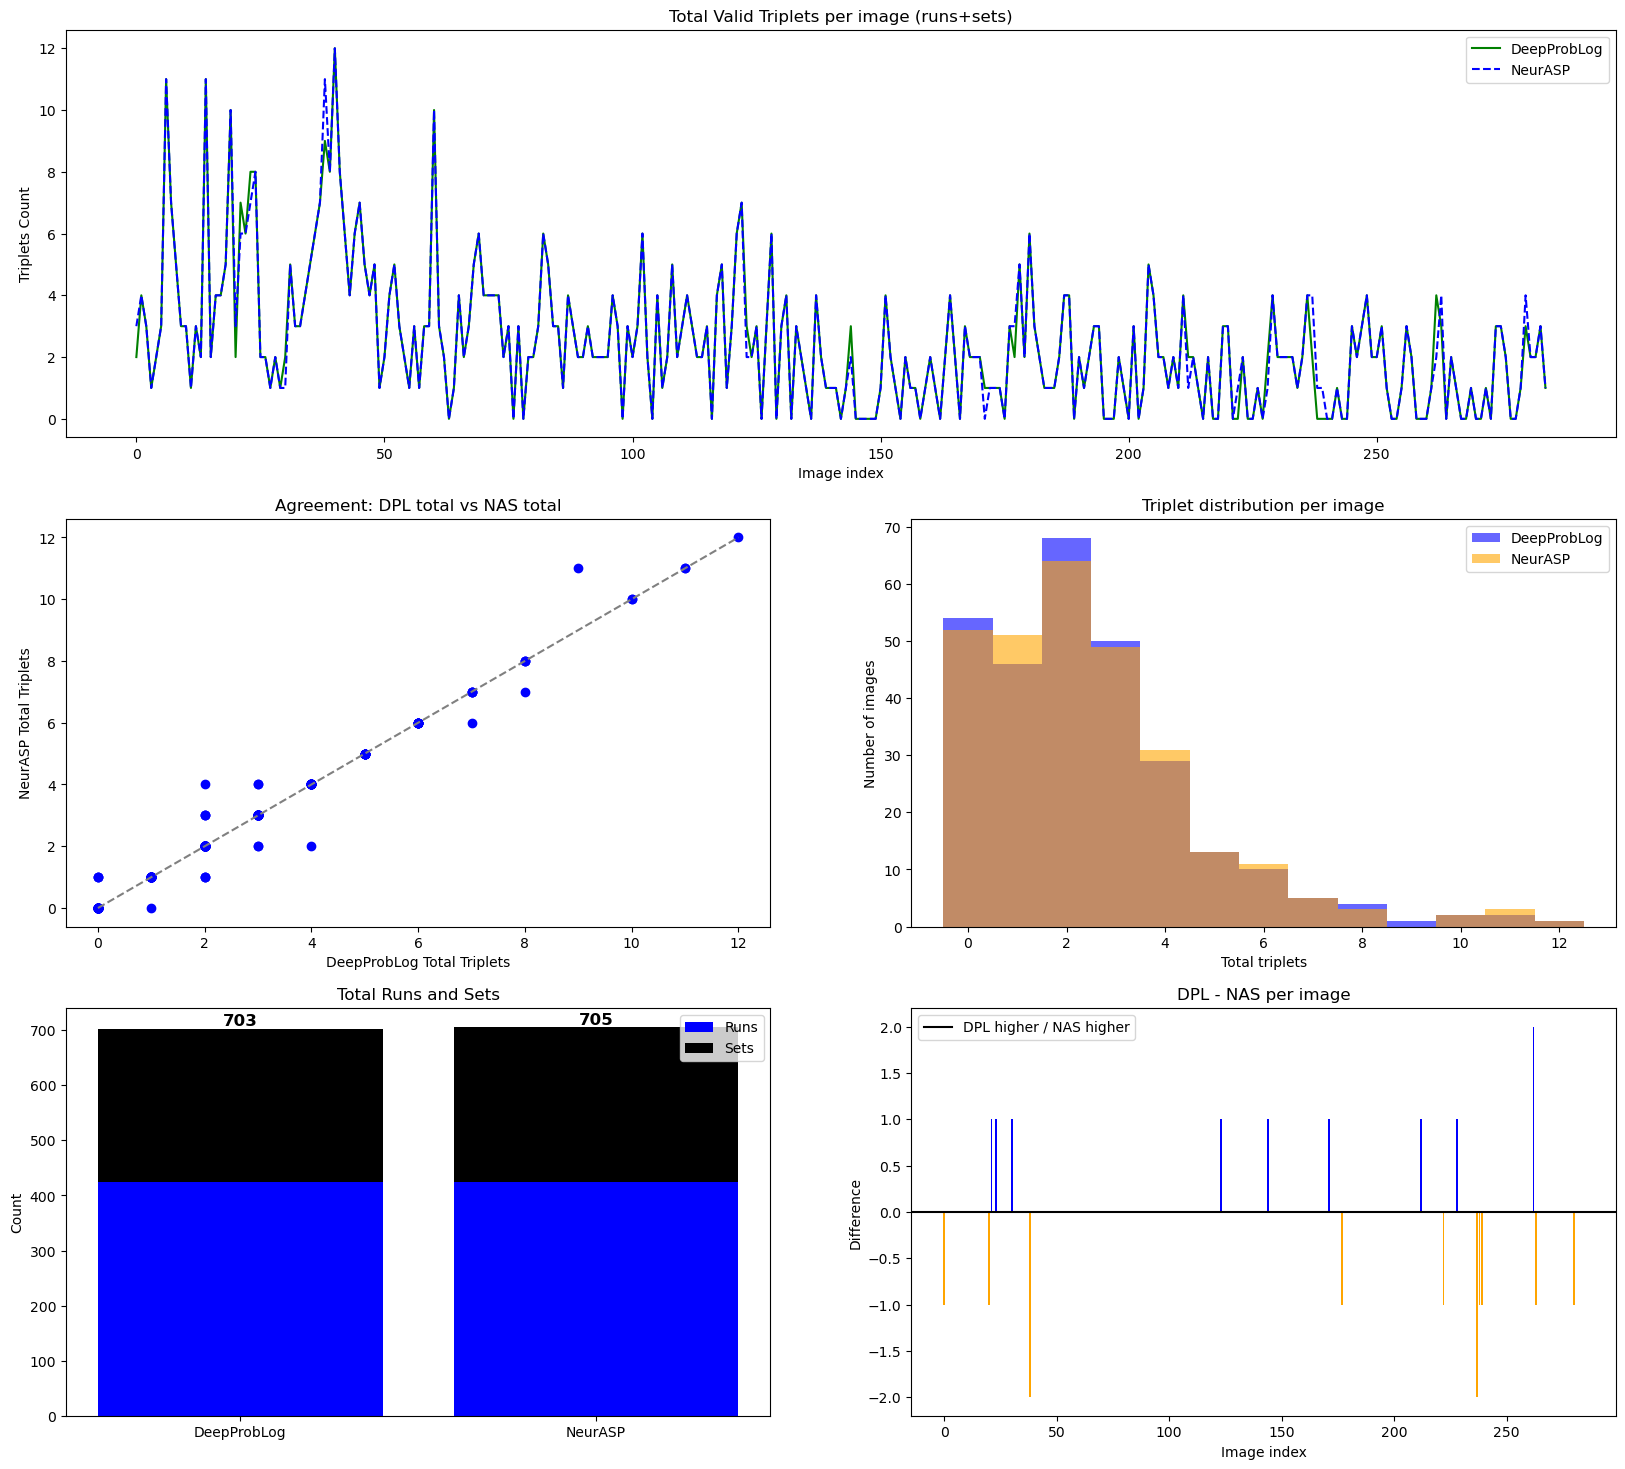

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import numpy as np
import json
from matplotlib.ticker import MaxNLocator

with open("deepproblog_results.json") as file:
    data_dr = json.load(file)
    dlog = {x["image"]: x for x in data_dr["results"]}
    dlog_time = data_dr["total_time"]

with open("neurasp_results.json") as file2:
    data_nasp = json.load(file2)
    nasp = {x["image"]: x for x in data_nasp["results"]}
    nasp_time = data_nasp["total_time"]

images = sorted(set(dlog)&set(nasp))
len_n = len(images)
index = np.arange(len_n)

deepproblog_run = np.array([dlog[x]["n_valid_run"] for x in images])
deepproblog_set = np.array([dlog[x]["n_valid_set"] for x in images])
NeurASP_run = np.array([nasp[x]["n_valid_run"] for x in images])
NeurASP_set = np.array([nasp[x]["n_valid_set"] for x in images])

deepproblog_time = np.array([dlog[x].get("time_seconds",0) for x in images])
NeurASP_time = np.array([nasp[x].get("time_seconds",0) for x in images])

deepproblog_total = deepproblog_run+deepproblog_set
NeurASP_total = NeurASP_run+NeurASP_set

agreement_run = len(np.where(deepproblog_run==NeurASP_run)[0])
agreement_set = len(np.where(deepproblog_set==NeurASP_set)[0])

total_agreement = len(np.where(deepproblog_total==NeurASP_total)[0])

print(f"deepproblog - total :{deepproblog_total.sum()} runs : {deepproblog_run.sum()} sets:{deepproblog_set.sum()}")
print(f"NeurASP - total :{NeurASP_total.sum()} runs : {NeurASP_run.sum()} sets:{NeurASP_set.sum()}")

print(f"Run Agreement : ({agreement_run/len_n*100:.2f}%) {agreement_run}/{len_n}")
print(f"Set Agreement : ({agreement_set/len_n*100:.2f}%) {agreement_set}/{len_n}")
print(f"Total Agreement : ({total_agreement/len_n*100:.2f}%) {total_agreement}/{len_n}")
print(f"Time Taken : Deepproblog_Time: {dlog_time:.2f}seconds NeurASP_Time: {nasp_time:.2f} seconds ")

#1st graph 
fig1 = plt.figure(figsize=(20, 18))
gs = gridspec.GridSpec(3, 2, figure=fig1)


ax_line = fig1.add_subplot(gs[0, :])
ax_line.plot(deepproblog_total, label="DeepProbLog", linestyle='-',color='Green')
ax_line.plot(NeurASP_total, label="NeurASP", linestyle='--',color="Blue")
ax_line.set_title("Total Valid Triplets per image (runs+sets)")
ax_line.set_xlabel("Image index")
ax_line.set_ylabel("Triplets Count")
ax_line.legend()

ax_sc = fig1.add_subplot(gs[1, 0])
ax_sc.scatter(deepproblog_total, NeurASP_total,color="blue", label="DeepProbLog vs NAS")
ax_sc.set_title("Agreement: DPL total vs NAS total")
ax_sc.set_xlabel("DeepProbLog Total Triplets")
ax_sc.set_ylabel("NeurASP Total Triplets")
max_val = max(deepproblog_total.max(), NeurASP_total.max())
ax_sc.plot([0, max_val], [0, max_val], linestyle="--", color="gray", label="Perfect match")

bins = np.arange(0, max(deepproblog_total.max(), NeurASP_total.max()) + 2) - 0.5
ax_hist = fig1.add_subplot(gs[1, 1])
ax_hist.hist(deepproblog_total,bins=bins, alpha=0.6, label="DeepProbLog",color="blue")
ax_hist.hist(NeurASP_total,bins=bins, alpha=0.6, label="NeurASP",color="orange")
ax_hist.set_title("Triplet distribution per image")
ax_hist.set_xlabel("Total triplets")
ax_hist.set_ylabel("Number of images")
ax_hist.legend()

ax_grand = fig1.add_subplot(gs[2, 0])
runs = [deepproblog_run.sum(), NeurASP_run.sum()]
sets = [deepproblog_set.sum(), NeurASP_set.sum()]
labels = ["DeepProbLog", "NeurASP"]
x = np.arange(len(labels))
ax_grand.bar(x, runs, label="Runs", color="blue")
ax_grand.bar(x, sets, bottom=runs, label="Sets", color="black")
ax_grand.set_xticks(x)
ax_grand.set_xticklabels(labels)
ax_grand.set_title("Total Runs and Sets")
ax_grand.set_ylabel("Count")
for i, (r, s) in enumerate(zip(runs, sets)):
    total = r + s
    ax_grand.text(i, total, str(total),
                  ha="center", va="bottom",
                  fontsize=12, fontweight="bold")
ax_grand.legend()

ax_diff = fig1.add_subplot(gs[2, 1])
diff = deepproblog_total - NeurASP_total
colors = ["blue" if d >= 0 else "orange" for d in diff]
ax_diff.bar(index, diff, color=colors)
ax_diff.axhline(0, color="black")
ax_diff.set_title("DPL - NAS per image")
ax_diff.set_xlabel("Image index")
ax_diff.set_ylabel("Difference")
ax_diff.legend(["DPL higher / NAS higher"])

plt.show()


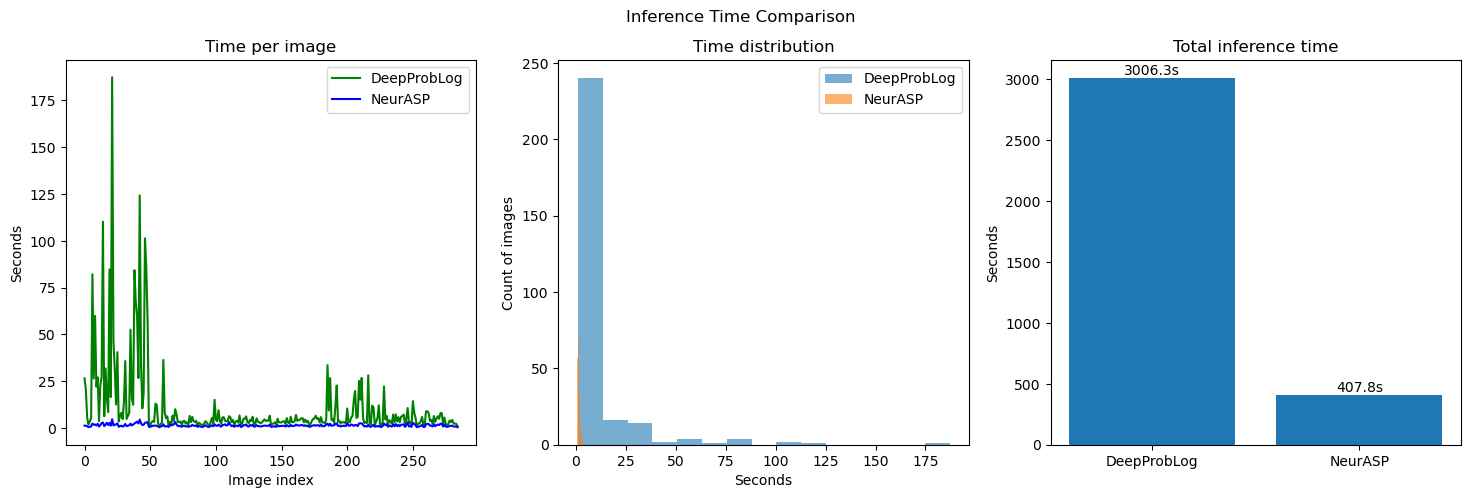

In [2]:
fig2, axes2 = plt.subplots(1, 3, figsize=(18, 5))

fig2.suptitle("Inference Time Comparison")

axes2[0].plot(deepproblog_time, label="DeepProbLog",color="Green")
axes2[0].plot(NeurASP_time, label="NeurASP",color="Blue")
axes2[0].set_title("Time per image")
axes2[0].set_xlabel("Image index")
axes2[0].set_ylabel("Seconds")
axes2[0].legend()

axes2[1].hist(deepproblog_time,bins=15, alpha=0.6, label="DeepProbLog")
axes2[1].hist(NeurASP_time,bins=15, alpha=0.6, label="NeurASP")
axes2[1].set_title("Time distribution")
axes2[1].set_xlabel("Seconds")
axes2[1].set_ylabel("Count of images")
axes2[1].legend()

times = [dlog_time, nasp_time]
labels = ["DeepProbLog", "NeurASP"]
axes2[2].bar(labels, times)
for i, t in enumerate(times):
    axes2[2].text(i, t, f"{t:.1f}s",
                  ha="center", va="bottom")
axes2[2].set_title("Total inference time")
axes2[2].set_ylabel("Seconds")
plt.show()